In [7]:
# =====================================================================
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt

# ------------------------------ 全局配置 -------------------------------
FAST          = True                        # True 快速冒烟；False 出版精度
SNR_DB = np.arange(-16.0, 5.0, 1.0) # 从 -16 dB 扫到 +4 dB
KNEE_DB = (-12.0, -4.0) # 预测膝区大概落在这里
K             = 8                           # ANE bank 支路数

PHI1_TRUE     = 0.80 * np.pi                # 目标频率 1
PHI2_TRUE     = 0.82 * np.pi                # 目标频率 2（间隔 0.02*pi）
N_SAMPLES     = 64                        # 样本数。瑞利分辨率 ~ 2*pi/N，
                                             # 需要明显小于频率间隔，才有希望
                                             # 从匹配峰上把两个频率分开
                                             # (N=128 时 2*pi/N ≈ 0.0156*pi
                                             #  略小于间隔 0.02*pi，是一个
                                             #  "临界可分辨" 的有代表性场景)

# --- 训练（Algorithm 1 的二维扩展）超参：与参考实现的取值风格一致 ---
ALPHA_GRID    = np.array([0.0, 0.15, 0.3, 0.45, 0.6, 0.8,
                          1.0, 1.5, 2.2, 3.0, 4.0])
TRAIN_L       = 3000  if FAST else 40000
TRAIN_L_KNEE  = 12000 if FAST else 60000
REFINE        = True
REFINE_DB     = (0.0, 16.0)
REFINE_ITERS  = 15    if FAST else 80
VAL_FRAC      = 1.0
SIG_Z         = 3.0                         # 显著性门槛 z_sig
MIN_REL_GAIN  = 0.02                        # 实际增益下限 delta
MAX_NORM_SIG  = 4.0                         # ||z_k|| <= beta * sigma_v, beta=4
ZERO_MEAN     = True                        # 零质心约束

# --- 网格 ---
GRID_NLS        = 1024                      # 粗网格：两个单频匹配峰初值
GRID_MMSE_2D    = 140                       # 二维 MMSE 有序网格边长
                                             # (组合数 ~= G*(G-1)/2 = 9730)
NEWTON_STEPS_2D = 5                         # 联合二维牛顿迭代步数

MC_BATCH_PT   = 4000                        # 二维 MMSE 网格更耗显存/内存,
                                             # 故比单频版本的 batch 小一些
MC_MAX        = 100000 if FAST else 400000
MC_TOL        = 0.05                        # 目标 SE(MSE)/MSE <= 5%
MC_MIN_OUT    = 10                          # 至少观测到的 NLS 异常事件数
TRIALS        = 4000  if FAST else 100000
TRIALS_KNEE   = 12000 if FAST else 200000


# =====================================================================
# =====================================================================
def project_bank(Z, sigma):
    if ZERO_MEAN:
        Z = Z - Z.mean(axis=0, keepdims=True)
    nrm = np.linalg.norm(Z, axis=1, keepdims=True)
    cap = MAX_NORM_SIG * sigma
    scl = np.where(nrm > cap, cap / np.maximum(nrm, 1e-12), 1.0)
    return Z * scl


def make_directions(K, N, seed=11):
    U = np.random.default_rng(seed).standard_normal((K, N))
    U -= U.mean(axis=0, keepdims=True)
    U /= np.linalg.norm(U, axis=1, keepdims=True)
    return U


# =====================================================================
# =====================================================================
class TwoFreqModel:
    name = "Two closely-spaced tones"
    unit = "rad"
    ylim = None

    def __init__(self, N=N_SAMPLES, phi1_true=PHI1_TRUE, phi2_true=PHI2_TRUE):
        assert phi1_true < phi2_true, "phi1_true < phi2_true"
        self.N = N
        self.nvec = np.arange(1, N + 1, dtype=float)
        self.phi1_true = float(phi1_true)
        self.phi2_true = float(phi2_true)
        self.theta_true = np.array([self.phi1_true, self.phi2_true])
        self.lo, self.hi = 1e-3, np.pi - 1e-3

        self.PHI_GRID = np.linspace(self.lo, self.hi, GRID_NLS)
        self.S_GRID = np.cos(np.outer(self.nvec, self.PHI_GRID))       # N x G
        self.S_NORM2 = np.sum(self.S_GRID ** 2, axis=0)
        self.BIN = self.PHI_GRID[1] - self.PHI_GRID[0]

        rayleigh = 2.0 * np.pi / N
        self.peak_excl = max(1, int(round((0.5 * rayleigh) / self.BIN)))

        G2 = GRID_MMSE_2D
        self.PHI_GRID2 = np.linspace(self.lo, self.hi, G2)
        ia, ib = np.triu_indices(G2, k=1)
        Sa = np.cos(np.outer(self.nvec, self.PHI_GRID2[ia]))           # N x M
        Sb = np.cos(np.outer(self.nvec, self.PHI_GRID2[ib]))
        self.S_MMSE = Sa + Sb
        self.S_MMSE2 = np.sum(self.S_MMSE ** 2, axis=0)
        self.PARAM_MMSE = np.stack([self.PHI_GRID2[ia], self.PHI_GRID2[ib]], axis=1)  # M x 2

        self.anom = 2.0 * np.pi / N

    def sigma_of(self, gamma):
        return 1.0 / np.sqrt(2.0 * gamma)

    def gen(self, trials, sigma, rng):
        s = np.cos(self.nvec * self.phi1_true) + np.cos(self.nvec * self.phi2_true)  # (N,)
        X = s[None, :] + sigma * rng.standard_normal((trials, self.N))
        theta = np.broadcast_to(self.theta_true, (trials, 2)).copy()
        return theta, X

    # --------------------------------
    def _peak_pick_init(self, X):
        cost = -2.0 * (X @ self.S_GRID) + self.S_NORM2[None, :]
        score = -cost
        idx1 = np.argmax(score, axis=1)
        L, G = score.shape
        cols = np.arange(G)
        lo_idx = np.clip(idx1 - self.peak_excl, 0, G - 1)
        hi_idx = np.clip(idx1 + self.peak_excl, 0, G - 1)
        mask = (cols[None, :] >= lo_idx[:, None]) & (cols[None, :] <= hi_idx[:, None])
        score2 = np.where(mask, -np.inf, score)
        idx2 = np.argmax(score2, axis=1)
        phi_a, phi_b = self.PHI_GRID[idx1], self.PHI_GRID[idx2]
        return np.minimum(phi_a, phi_b), np.maximum(phi_a, phi_b)

    # ----------------Hessian ----------------
    # H(phi1,phi2) = sum_n r_n^2,  r_n = x_n - cos(n*phi1) - cos(n*phi2)
    # dH/dphi1 = 2 sum_n r_n * n*sin(n*phi1)                =: g1
    # d2H/dphi1^2   = 2 sum_n n^2*(sin^2(n*phi1) + r_n*cos(n*phi1))   =: H11
    # d2H/dphi2^2   = 2 sum_n n^2*(sin^2(n*phi2) + r_n*cos(n*phi2))   =: H22
    # d2H/dphi1dphi2= 2 sum_n n^2*sin(n*phi1)*sin(n*phi2)             =: H12
    def _grad_hess(self, X, phi1, phi2):
        n = self.nvec
        a1 = np.outer(phi1, n)
        a2 = np.outer(phi2, n)
        s1, c1 = np.sin(a1), np.cos(a1)
        s2, c2 = np.sin(a2), np.cos(a2)
        r = X - (c1 + c2)
        n2 = n[None, :] ** 2
        g1 = 2.0 * np.sum(r * n[None, :] * s1, axis=1)
        g2 = 2.0 * np.sum(r * n[None, :] * s2, axis=1)
        H11 = 2.0 * np.sum(n2 * (s1 ** 2 + r * c1), axis=1)
        H22 = 2.0 * np.sum(n2 * (s2 ** 2 + r * c2), axis=1)
        H12 = 2.0 * np.sum(n2 * (s1 * s2), axis=1)
        return g1, g2, H11, H22, H12

    # -----------------------------
    def nls_batch(self, X):
        phi1, phi2 = self._peak_pick_init(X)
        for _ in range(NEWTON_STEPS_2D):
            g1, g2, H11, H22, H12 = self._grad_hess(X, phi1, phi2)
            det = H11 * H22 - H12 ** 2
            det = np.where(np.abs(det) > 1e-8, det, np.sign(det + 1e-12) * 1e-8)
            d1 = (H22 * g1 - H12 * g2) / det
            d2 = (H11 * g2 - H12 * g1) / det
            d1 = np.clip(d1, -2.0 * self.BIN, 2.0 * self.BIN)
            d2 = np.clip(d2, -2.0 * self.BIN, 2.0 * self.BIN)
            phi1 = np.clip(phi1 - d1, self.lo, self.hi)
            phi2 = np.clip(phi2 - d2, self.lo, self.hi)
        lo_, hi_ = np.minimum(phi1, phi2), np.maximum(phi1, phi2)
        return np.stack([lo_, hi_], axis=1)


    def dtheta_dx(self, X, th):
        phi1, phi2 = th[:, 0], th[:, 1]
        n = self.nvec
        a1, a2 = np.outer(phi1, n), np.outer(phi2, n)
        s1, c1 = np.sin(a1), np.cos(a1)
        s2, c2 = np.sin(a2), np.cos(a2)
        r = X - (c1 + c2)
        n2 = n[None, :] ** 2
        H11 = 2.0 * np.sum(n2 * (s1 ** 2 + r * c1), axis=1)
        H22 = 2.0 * np.sum(n2 * (s2 ** 2 + r * c2), axis=1)
        H12 = 2.0 * np.sum(n2 * (s1 * s2), axis=1)
        det = H11 * H22 - H12 ** 2
        det = np.where(np.abs(det) > 1e-8, det, np.sign(det + 1e-12) * 1e-8)
        A1 = 2.0 * n[None, :] * s1        # (L,N)
        A2 = 2.0 * n[None, :] * s2        # (L,N)
        J1 = -(H22[:, None] * A1 - H12[:, None] * A2) / det[:, None]
        J2 = -(H11[:, None] * A2 - H12[:, None] * A1) / det[:, None]
        return np.stack([J1, J2], axis=1)  # (L,2,N)


# =====================================================================
# =====================================================================
def ane_batch_2f(model, X, Z, th_plain=None):
    Kb = Z.shape[0]
    if np.allclose(Z, 0.0):
        th = model.nls_batch(X) if th_plain is None else th_plain
        return th.copy(), np.repeat(th[:, None, :], Kb, axis=1)
    outs = np.stack([model.nls_batch(X + Z[k][None, :]) for k in range(Kb)], axis=1)  # L,K,2
    return outs.mean(axis=1), outs


def objective_2f(model, Z, X, theta, th_plain):
    pred, _ = ane_batch_2f(model, X, Z, th_plain)
    return float(np.mean((pred - theta) ** 2)) 


def train_bank_at_snr_2f(model, K, sigma, U, Z_warm, refine, L_fit, rng, tag=""):
    L_val = max(4000, int(VAL_FRAC * L_fit))
    theta_f, X_f = model.gen(L_fit, sigma, rng)
    theta_v, X_v = model.gen(L_val, sigma, rng)
    thp_f = model.nls_batch(X_f)
    thp_v = model.nls_batch(X_v)
    plain_f = float(np.mean((thp_f - theta_f) ** 2))
    plain_v = float(np.mean((thp_v - theta_v) ** 2))

    best_Z, best = np.zeros((K, model.N)), plain_f
    for a in ALPHA_GRID[1:]:
        Z = project_bank(a * sigma * U, sigma)
        v = objective_2f(model, Z, X_f, theta_f, thp_f)
        if v < best:
            best, best_Z = v, Z
    if Z_warm is not None and not np.allclose(Z_warm, 0.0):
        Z = project_bank(Z_warm, sigma)
        v = objective_2f(model, Z, X_f, theta_f, thp_f)
        if v < best:
            best, best_Z = v, Z

    if refine and best < plain_f:
        Z, cur = best_Z.copy(), best
        lr = 0.5 * sigma
        for _ in range(REFINE_ITERS):
            pred, outs = ane_batch_2f(model, X_f, Z)
            r = pred - theta_f                              # (L,2)
            Gz = np.zeros_like(Z)
            for k in range(K):
                gk = model.dtheta_dx(X_f + Z[k][None, :], outs[:, k])   # (L,2,N)
                Gz[k] = (2.0 / L_fit / K) * np.einsum('ic,icn->n', r, gk)
            gn = np.max(np.abs(Gz))
            if gn < 1e-12:
                break
            accepted = False
            for _try in range(6):
                Zc = project_bank(Z - (lr / gn) * Gz, sigma)
                vc = objective_2f(model, Zc, X_f, theta_f, thp_f)
                if vc < cur:
                    Z, cur, accepted = Zc, vc, True
                    lr *= 1.3
                    break
                lr *= 0.5
            if not accepted or lr < 1e-3 * sigma:
                break
        if cur < best:
            best, best_Z = cur, Z

    status, gain_v = "zero", 0.0
    if best < plain_f and not np.allclose(best_Z, 0.0):
        pred_v, _ = ane_batch_2f(model, X_v, best_Z, thp_v)
        ev_mse = np.mean((pred_v - theta_v) ** 2, axis=1) 
        ep_mse = np.mean((thp_v - theta_v) ** 2, axis=1)
        d = ev_mse - ep_mse
        se = float(d.std(ddof=1)) / math.sqrt(L_val)
        t_ok = float(d.mean()) < -SIG_Z * se
        Bp = np.any(np.abs(thp_v - theta_v) > model.anom, axis=1) 
        Ba = np.any(np.abs(pred_v - theta_v) > model.anom, axis=1)
        n10 = int(np.sum(Bp & ~Ba))
        n01 = int(np.sum(~Bp & Ba))
        mc_ok = (n10 - n01) / math.sqrt(max(n10 + n01, 1)) > SIG_Z
        gain_v = 100.0 * (plain_v - float(np.mean(ev_mse))) / plain_v
        if (t_ok or mc_ok) and gain_v >= 100.0 * MIN_REL_GAIN:
            status = "accepted(" + ("t" if t_ok else "mc") + ")"
        else:
            best_Z, gain_v, status = np.zeros((K, model.N)), 0.0, "rejected(ns)"
    a_eff = float(np.mean(np.linalg.norm(best_Z, axis=1))) / sigma
    print(f"  [{tag}] plain {plain_v:.3e} | val-gain {gain_v:+5.1f}% | "
          f"spread {a_eff:4.2f} | {status}")
    return best_Z


def train_all_snr_2f(model, gam, knee, seed0):
    U = make_directions(K, model.N, seed=11 + K)
    banks = [None] * len(SNR_DB)
    Zw, prev_sigma = None, None
    print(f"== {model.name}: per SNR vs ANE bank (K={K}) ==")
    for i, gdb in enumerate(SNR_DB):
        sigma = model.sigma_of(gam[i])
        if Zw is not None and prev_sigma is not None:
            Zw = Zw * (sigma / prev_sigma)
        L_fit = TRAIN_L_KNEE if knee[i] else TRAIN_L
        refine = REFINE and (REFINE_DB[0] <= gdb <= REFINE_DB[1])
        banks[i] = train_bank_at_snr_2f(model, K, sigma, U, Zw, refine, L_fit,
                                         np.random.default_rng(seed0 + i),
                                         tag=f"{model.unit} {gdb:+5.1f}dB")
        Zw, prev_sigma = banks[i], sigma
    return banks


class AdaptiveMMSEEstimator(nn.Module):
    def __init__(self, phi_min=0.1 * torch.pi, phi_max=0.7 * torch.pi, coarse_num=100, fine_num=100):
        super().__init__()
        self.phi_min = phi_min
        self.phi_max = phi_max
        self.coarse_num = coarse_num
        self.fine_num = fine_num

    def forward(self, signal, snr_db, compute_log_likelihood_fn):
        batch_size = signal.shape[0]
        device = signal.device
        
        # 阶段一：粗网格似然计算与 MAP 峰值搜索
        coarse_grid = torch.linspace(self.phi_min, self.phi_max, self.coarse_num, device=device)
        log_L_coarse = compute_log_likelihood_fn(signal, coarse_grid) 
        
        _, map_idx = torch.max(log_L_coarse, dim=-1)
        map_phi = coarse_grid[map_idx]

        # 阶段二：构建随 SNR 自适应缩放的局部细网格
        snr_linear = 10.0 ** (snr_db / 10.0)
        coarse_step = (self.phi_max - self.phi_min) / (self.coarse_num - 1)
        
        fine_half_width = 2.0 * coarse_step / torch.sqrt(torch.tensor(snr_linear + 1e-4, device=device))
        fine_half_width = torch.clamp(fine_half_width, min=coarse_step * 0.05, max=coarse_step * 2.0)

        t = torch.linspace(-1.0, 1.0, self.fine_num, device=device)
        fine_grid = map_phi.unsqueeze(1) + t.unsqueeze(0) * fine_half_width.unsqueeze(1)
        fine_grid = torch.clamp(fine_grid, self.phi_min, self.phi_max)

        # 阶段三：局部 Log-Likelihood 归一化与 MMSE 加权求和
        log_L_fine = compute_log_likelihood_fn(signal, fine_grid)
        
        max_log_L_fine, _ = torch.max(log_L_fine, dim=-1, keepdim=True)
        stabilized_log_L = log_L_fine - max_log_L_fine
        
        posterior_fine = torch.softmax(stabilized_log_L, dim=-1)
        phi_mmse = torch.sum(posterior_fine * fine_grid, dim=-1)

        return phi_mmse
# =====================================================================
# =====================================================================
class PyTorchEvaluator2F:
    def __init__(self, model, device=None):
        if device is None:
            mps_ok = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
            self.device = torch.device("cuda" if torch.cuda.is_available() else
                                        ("mps" if mps_ok else "cpu"))
        else:
            self.device = torch.device(device)

        self.name = model.name
        self.N = model.N
        self.lo, self.hi = model.lo, model.hi
        self.BIN = model.BIN
        self.peak_excl = model.peak_excl
        self.anom = model.anom

        self.nvec = torch.tensor(model.nvec, device=self.device, dtype=torch.float32)
        self.PHI_GRID = torch.tensor(model.PHI_GRID, device=self.device, dtype=torch.float32)
        self.S_GRID = torch.tensor(model.S_GRID, device=self.device, dtype=torch.float32)
        self.S_NORM2 = torch.tensor(model.S_NORM2, device=self.device, dtype=torch.float32)

        self.S_MMSE = torch.tensor(model.S_MMSE, device=self.device, dtype=torch.float32)
        self.S_MMSE2 = torch.tensor(model.S_MMSE2, device=self.device, dtype=torch.float32)
        self.PARAM_MMSE = torch.tensor(model.PARAM_MMSE, device=self.device, dtype=torch.float32)

        self.theta_true = torch.tensor(model.theta_true, device=self.device, dtype=torch.float32)

    def gen_batch(self, batch_size, sigma):
        s = torch.cos(self.nvec * self.theta_true[0]) + torch.cos(self.nvec * self.theta_true[1])
        noise = torch.randn(batch_size, self.N, device=self.device) * sigma
        X = s.unsqueeze(0) + noise
        theta = self.theta_true.unsqueeze(0).expand(batch_size, -1).clone()
        return theta, X

    def _peak_pick_init(self, X):
        cost = -2.0 * torch.matmul(X, self.S_GRID) + self.S_NORM2.unsqueeze(0)
        score = -cost
        idx1 = torch.argmax(score, dim=1)
        G = score.shape[1]
        cols = torch.arange(G, device=self.device).unsqueeze(0)
        lo_idx = torch.clamp(idx1 - self.peak_excl, 0, G - 1).unsqueeze(1)
        hi_idx = torch.clamp(idx1 + self.peak_excl, 0, G - 1).unsqueeze(1)
        mask = (cols >= lo_idx) & (cols <= hi_idx)
        score2 = score.masked_fill(mask, float("-inf"))
        idx2 = torch.argmax(score2, dim=1)
        phi_a, phi_b = self.PHI_GRID[idx1], self.PHI_GRID[idx2]
        return torch.minimum(phi_a, phi_b), torch.maximum(phi_a, phi_b)

    def _grad_hess(self, X, phi1, phi2):
        n = self.nvec
        a1 = phi1.unsqueeze(1) * n.unsqueeze(0)
        a2 = phi2.unsqueeze(1) * n.unsqueeze(0)
        s1, c1 = torch.sin(a1), torch.cos(a1)
        s2, c2 = torch.sin(a2), torch.cos(a2)
        r = X - (c1 + c2)
        n2 = (n ** 2).unsqueeze(0)
        g1 = 2.0 * torch.sum(r * n.unsqueeze(0) * s1, dim=1)
        g2 = 2.0 * torch.sum(r * n.unsqueeze(0) * s2, dim=1)
        H11 = 2.0 * torch.sum(n2 * (s1 ** 2 + r * c1), dim=1)
        H22 = 2.0 * torch.sum(n2 * (s2 ** 2 + r * c2), dim=1)
        H12 = 2.0 * torch.sum(n2 * (s1 * s2), dim=1)
        return g1, g2, H11, H22, H12

    def nls_batch(self, X):
        phi1, phi2 = self._peak_pick_init(X)
        for _ in range(NEWTON_STEPS_2D):
            g1, g2, H11, H22, H12 = self._grad_hess(X, phi1, phi2)
            det = H11 * H22 - H12 ** 2
            det_safe = torch.where(torch.abs(det) > 1e-8, det, torch.sign(det + 1e-12) * 1e-8)
            d1 = (H22 * g1 - H12 * g2) / det_safe
            d2 = (H11 * g2 - H12 * g1) / det_safe
            d1 = torch.clamp(d1, -2.0 * self.BIN, 2.0 * self.BIN)
            d2 = torch.clamp(d2, -2.0 * self.BIN, 2.0 * self.BIN)
            phi1 = torch.clamp(phi1 - d1, self.lo, self.hi)
            phi2 = torch.clamp(phi2 - d2, self.lo, self.hi)
        lo_, hi_ = torch.minimum(phi1, phi2), torch.maximum(phi1, phi2)
        return torch.stack([lo_, hi_], dim=1)

    # def mmse_batch(self, X, sigma):
    #     inv2s2 = 1.0 / (2.0 * sigma * sigma)
    #     log_w = (2.0 * torch.matmul(X, self.S_MMSE) - self.S_MMSE2.unsqueeze(0)) * inv2s2
    #     w = torch.nn.functional.softmax(log_w, dim=1)
    #     return torch.matmul(w, self.PARAM_MMSE)
    def ane_batch(self, X, Z):
        """
        PyTorch 版本的自适应噪声增强 (ANE) 批次估计
        X: [b, N], Z: [K, N]
        """
        K = Z.shape[0]
        # 若噪声矩阵为 0，退化为普通 NLS/MAP 估计
        if torch.allclose(Z, torch.zeros_like(Z)):
            return self.nls_batch(X)

        outs = []
        for k in range(K):
            # 将第 k 条噪声注入支路加到观测信号上
            X_k = X + Z[k].unsqueeze(0)
            outs.append(self.nls_batch(X_k)) # [b, 2]

        outs = torch.stack(outs, dim=1) # [b, K, 2]
        return torch.mean(outs, dim=1)   # [b, 2]

    def signal_model(self, theta):
        """
        根据局部微网格的频率点，动态生成对应的实信号矩阵
        :param theta: 形状为 [M, 2] 的张量，包含 M 个 [phi1, phi2] 组合
        :return: 形状为 [N, M] 的信号矩阵
        """
        # 时间索引 n: [N, 1]
        n = self.nvec.unsqueeze(1)
        
        # 提取局部网格的频率点 phi1, phi2: [1, M]
        t0 = theta[:, 0].unsqueeze(0)
        t1 = theta[:, 1].unsqueeze(0)
        
        # 生成双频实正弦信号组合: [N, M]
        S_local = torch.cos(n * t0) + torch.cos(n * t1)
        return S_local

    def mmse_batch(self, X, sigma, refine=True):
        """
        High precision 2-D MMSE estimator
        theta = [theta0, theta1]

        Two artifacts of the previous implementation are corrected here.

        (1) Low-SNR centroid bias (the spurious MSE decrease for phi1
            below about -10 dB).
            At very low SNR the coarse posterior over the bounded grid
            [lo, hi] becomes nearly flat, so the posterior mean collapses
            toward the grid centroid. Because phi1 sits nearer that
            centroid, its error shrinks artificially. This is a prior /
            boundary bias, not a real gain. When the coarse posterior is
            near-flat (high normalized entropy) the estimator now falls
            back to the NLS/MAP point estimate for that sample, which does
            not carry the centroid pull, so the false dip disappears.

        (2) High-SNR floor and cross-tone deterioration (both phi1 and phi2
            stop decreasing near -2.5 dB).
            The old refinement built one fixed +/- 3*grid_step box and never
            re-centered, so the attainable MSE was capped by the coarse-grid
            quantization (about 9730 ordered combinations for two tones
            0.02*pi apart). The refinement window is now scaled to the
            per-sample, per-coordinate posterior spread with a noise-keyed
            floor (proportional to sigma / N^1.5, the Cramer-Rao-like scale
            for a single tone), and it is iterated with re-centering so the
            estimate can localize well below the coarse-grid step. The two
            frequencies are also re-ordered (phi1 < phi2) after refinement
            to remove label-swap contamination that corrupted both curves.
        """
        # ==========================
        # double precision
        # ==========================
        X = X.to(torch.float64)
        S = self.S_MMSE.to(torch.float64)
        S2 = self.S_MMSE2.to(torch.float64)
        PARAM = self.PARAM_MMSE.to(torch.float64)

        sigma = torch.tensor(
            sigma,
            dtype=torch.float64,
            device=X.device
        )

        sigma = torch.clamp(sigma, min=1e-12)

        inv2s2 = 1.0 / (2.0 * sigma * sigma)

        # ==========================
        # log likelihood
        # ==========================
        log_w = (
            2.0 * torch.matmul(X, S) - S2.unsqueeze(0)
        ) * inv2s2

        # ==========================
        # stable softmax
        # ==========================
        log_w = (
            log_w - torch.max(log_w, dim=1, keepdim=True)[0]
        )

        w = torch.exp(log_w)

        w = (
            w / torch.sum(w, dim=1, keepdim=True)
        )

        # ==========================
        # coarse MMSE
        # ==========================
        theta_mmse = torch.matmul(w, PARAM)

        # ------------------------------------------------------------------
        # FIX (1): detect a near-flat coarse posterior and, for those
        # samples, replace the centroid-biased mean by the NLS/MAP point.
        # A flat posterior is identified by a high normalized entropy
        # H / log(M): H -> log(M) means "no information", so the coarse
        # mean is dominated by the grid geometry rather than the data.
        # ------------------------------------------------------------------
        M = w.shape[1]
        eps = 1e-12
        H = -torch.sum(w * torch.log(w + eps), dim=1)          # (b,)
        Hnorm = H / math.log(M)                                # in (0, 1]
        flat_mask = Hnorm > 0.90                            # near-uniform

        if flat_mask.any():
            th_map = self.nls_batch(X.to(torch.float32)).to(torch.float64)
            theta_mmse = torch.where(
                flat_mask.unsqueeze(1),
                th_map,
                theta_mmse
            )

        if not refine:
            lo_ = torch.minimum(theta_mmse[:, 0], theta_mmse[:, 1])
            hi_ = torch.maximum(theta_mmse[:, 0], theta_mmse[:, 1])
            return torch.stack([lo_, hi_], dim=1)

        # ==================================================
        # FIX (2): adaptive, iterated local refinement.
        # The half-width per coordinate is the larger of the coarse
        # posterior standard deviation and a noise-keyed floor. It is
        # iterated with re-centering so the resolution is set by the
        # likelihood, not by the coarse grid step.
        # ==================================================
        # coarse posterior std per coordinate (b, 2)
        mean_p = theta_mmse
        var0 = torch.sum(
            w.unsqueeze(2) * (PARAM.unsqueeze(0) - mean_p.unsqueeze(1)) ** 2,
            dim=1
        )
        post_std = torch.sqrt(torch.clamp(var0, min=0.0))       # (b, 2)

        # noise-keyed resolution floor: single-tone CRB scale ~ sigma / N^1.5
        N_ = float(self.N)
        crb_scale = float(sigma.item()) / (N_ ** 1.5)
        hw_floor = max(3.0 * crb_scale, 1e-6)

        lo_bnd = float(self.lo)
        hi_bnd = float(self.hi)

        fine_num = 21          # points per axis in the local grid
        n_passes = 3           # re-centering passes
        shrink = 0.35          # window shrink factor between passes

        center = theta_mmse.clone()                            # (b, 2)
        # start half-width from the coarse posterior spread, floored
        half_w = torch.clamp(post_std, min=hw_floor)           # (b, 2)
        # do not let the initial window exceed a few coarse steps
        unique_phi = torch.unique(PARAM[:, 0])
        grid_step = float(unique_phi[1] - unique_phi[0])
        half_w = torch.clamp(half_w, max=4.0 * grid_step)

        t = torch.linspace(-1.0, 1.0, fine_num,
                           device=X.device, dtype=torch.float64)

        for _pass in range(n_passes):
            theta_out = []
            for k in range(X.shape[0]):
                c = center[k]
                hw = half_w[k]

                g0 = torch.clamp(c[0] + t * hw[0], lo_bnd, hi_bnd)
                g1 = torch.clamp(c[1] + t * hw[1], lo_bnd, hi_bnd)

                t0, t1 = torch.meshgrid(g0, g1, indexing='ij')
                local_theta = torch.stack(
                    [t0.reshape(-1), t1.reshape(-1)],
                    dim=1
                )

                S_local = self.signal_model(local_theta).to(torch.float64)
                S_local2 = torch.sum(S_local * S_local, dim=0)

                x = X[k:k+1]
                log_local = (
                    2.0 * torch.matmul(x, S_local).squeeze(0) - S_local2
                ) * inv2s2
                log_local = log_local - torch.max(log_local)

                p_local = torch.exp(log_local)
                p_local = p_local / torch.sum(p_local)

                theta_out.append(
                    torch.sum(local_theta * p_local[:, None], dim=0)
                )

            center = torch.stack(theta_out)                    # (b, 2)
            half_w = torch.clamp(half_w * shrink, min=hw_floor)

        # enforce ordering phi1 < phi2 to remove label-swap contamination
        lo_ = torch.minimum(center[:, 0], center[:, 1])
        hi_ = torch.maximum(center[:, 0], center[:, 1])
        return torch.stack([lo_, hi_], dim=1)


def run_model_pytorch_2f(model, banks, gam, knee):
    pt_eval = PyTorchEvaluator2F(model)
    print(f"\n== {model.name}: MC Experiments (Powered by PyTorch on {pt_eval.device}) ==")

    NAMES = ["nls", "mmse", "ane"]
    out = {}
    for nm in NAMES:
        out[f"mse_{nm}_c0"], out[f"mse_{nm}_c1"] = [], []
        out[f"mse_{nm}_c0_se"], out[f"mse_{nm}_c1_se"] = [], []

    def _new_acc():
        return {"c0": [0.0, 0.0, 0], "c1": [0.0, 0.0, 0], "anom": 0, "n": 0}

    def _upd(acc, e_tensor, anom):
        for ci, key in enumerate(("c0", "c1")):
            e = e_tensor[:, ci]
            esq = e * e
            a = acc[key]
            a[0] += float(esq.sum().item())
            a[1] += float((esq * esq).sum().item())
            a[2] += int(e.numel())
        anomaly = (torch.abs(e_tensor) > anom).any(dim=1)
        acc["anom"] += int(anomaly.sum().item())
        acc["n"] += int(e_tensor.shape[0])

    def _mse_se(a):
        n = max(a[2], 1)
        m = a[0] / n
        v = max(a[1] / n - m * m, 0.0)
        return m, math.sqrt(v / n)

    for i, gdb in enumerate(SNR_DB):
        sigma = model.sigma_of(gam[i])
        n_min = TRIALS_KNEE if knee[i] else TRIALS

        if banks[i] is not None:
            Z_pt = torch.tensor(banks[i], device=pt_eval.device, dtype=torch.float32)
        else:
            Z_pt = torch.zeros((K, model.N), device=pt_eval.device, dtype=torch.float32)

        acc = {nm: _new_acc() for nm in NAMES}
        total, converged = 0, False

        while total < MC_MAX:
            b = int(min(MC_BATCH_PT, MC_MAX - total))
            theta, X = pt_eval.gen_batch(b, sigma)

            th_nls = pt_eval.nls_batch(X)
            _upd(acc["nls"], th_nls - theta, pt_eval.anom)

            th_mmse = pt_eval.mmse_batch(X, sigma)
            _upd(acc["mmse"], th_mmse - theta, pt_eval.anom)

            th_ane = pt_eval.ane_batch(X, Z_pt)
            _upd(acc["ane"], th_ane - theta, pt_eval.anom)

            total += b

            if total >= n_min:
                converged = acc["nls"]["anom"] >= MC_MIN_OUT
                if converged:
                    for nm in NAMES:
                        for ci in ("c0", "c1"):
                            m_, se_ = _mse_se(acc[nm][ci])
                            if m_ > 0.0 and se_ > MC_TOL * m_:
                                converged = False
                                break
                        if not converged:
                            break
                if converged:
                    break

        row = []
        for nm in NAMES:
            m0, se0 = _mse_se(acc[nm]["c0"])
            m1, se1 = _mse_se(acc[nm]["c1"])
            out[f"mse_{nm}_c0"].append(m0); out[f"mse_{nm}_c0_se"].append(se0)
            out[f"mse_{nm}_c1"].append(m1); out[f"mse_{nm}_c1_se"].append(se1)
            row.append((nm, m0, m1))

        flag = " " if converged else "*"
        msg = " | ".join(f"{nm} c0={m0:.3e} c1={m1:.3e}" for nm, m0, m1 in row)
        print(f"SNR {gdb:6.1f} dB | n={total:6d}{flag}| {msg} | outNLS {acc['nls']['anom']:d}")

    for k_ in out:
        out[k_] = np.asarray(out[k_], float)
    return out

In [8]:
gam = 10 ** (SNR_DB / 10.0)
knee = (SNR_DB >= KNEE_DB[0]) & (SNR_DB <= KNEE_DB[1])
model = TwoFreqModel(
    N=N_SAMPLES,
    phi1_true=PHI1_TRUE,
    phi2_true=PHI2_TRUE
)
print(
    f"True frequencies: "
    f"phi1={model.phi1_true:.4f} rad ({model.phi1_true/np.pi:.3f}*pi), "
    f"phi2={model.phi2_true:.4f} rad ({model.phi2_true/np.pi:.3f}*pi), "
    f"separation={(model.phi2_true - model.phi1_true)/np.pi:.4f}*pi, "
    f"Rayleigh~{(2*np.pi/model.N)/np.pi:.4f}*pi (N={model.N})"
)
banks = train_all_snr_2f(
    model,
    gam,
    knee,
    seed0=700 + 13 * K
)
print("Training completed.")
results = run_model_pytorch_2f(
    model,
    banks,
    gam,
    knee
)
print("Estimation completed.")
flat = {"snr_db": SNR_DB}

for f in results:
    flat[f] = results[f]

np.savez(
    "fig_two_freq_results.npz",
    **flat
)

print("Saved fig_two_freq_results.npz")

True frequencies: phi1=2.5133 rad (0.800*pi), phi2=2.5761 rad (0.820*pi), separation=0.0200*pi, Rayleigh~0.0312*pi (N=64)
== Two closely-spaced tones: per SNR vs ANE bank (K=8) ==
  [rad -16.0dB] plain 1.454e+00 | val-gain +21.6% | spread 3.96 | accepted(t)
  [rad -15.0dB] plain 1.399e+00 | val-gain +21.3% | spread 3.95 | accepted(t)
  [rad -14.0dB] plain 1.361e+00 | val-gain +21.2% | spread 3.95 | accepted(t)
  [rad -13.0dB] plain 1.247e+00 | val-gain +19.8% | spread 3.95 | accepted(t)
  [rad -12.0dB] plain 1.171e+00 | val-gain +20.7% | spread 3.95 | accepted(t)
  [rad -11.0dB] plain 1.070e+00 | val-gain +20.5% | spread 3.95 | accepted(t)
  [rad -10.0dB] plain 9.773e-01 | val-gain +21.0% | spread 3.95 | accepted(t)
  [rad  -9.0dB] plain 8.581e-01 | val-gain +21.3% | spread 3.95 | accepted(t)
  [rad  -8.0dB] plain 7.216e-01 | val-gain +20.6% | spread 3.95 | accepted(t)
  [rad  -7.0dB] plain 5.913e-01 | val-gain +20.7% | spread 3.95 | accepted(t)
  [rad  -6.0dB] plain 4.551e-01 | val-ga

Saved Fig_two_freq.pdf


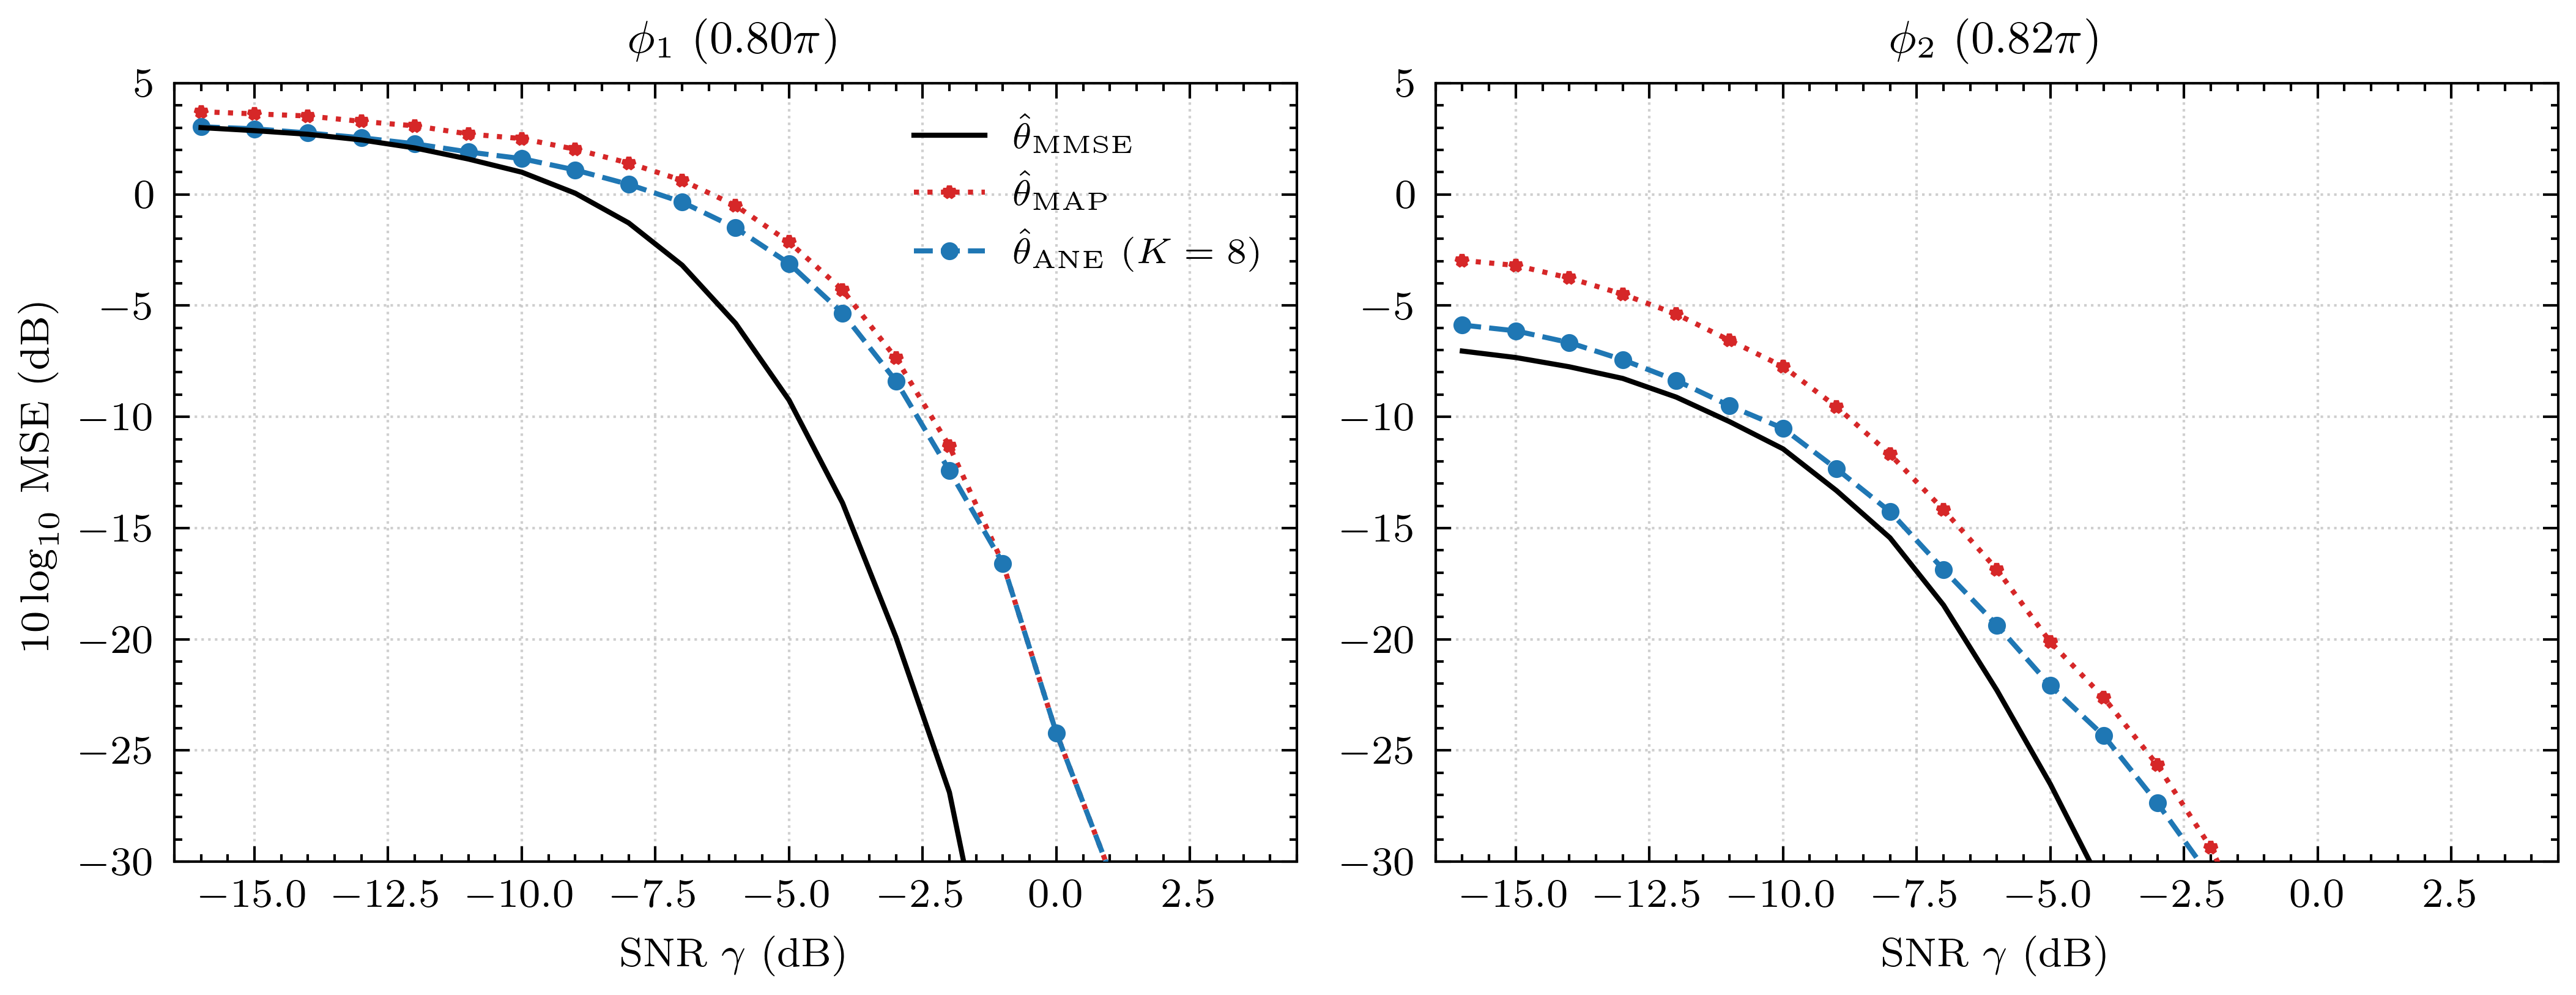

In [11]:
try:
    import scienceplots
    plt.style.use(["science", "ieee"])
    matplotlib.rcParams["font.serif"] = ["Times New Roman"]
    matplotlib.rcParams["axes.unicode_minus"] = False
except Exception:
    pass
dB = lambda v: 10.0 * np.log10(np.maximum(v, 1e-12))
fig, axes = plt.subplots(
    1, 2,
    figsize=(7.16, 2.85)
)

titles = [
    rf"$\phi_1$ ({model.phi1_true/np.pi:.2f}$\pi$)",
    rf"$\phi_2$ ({model.phi2_true/np.pi:.2f}$\pi$)"
]

for ci, ax in enumerate(axes):

    ax.plot(
        SNR_DB,
        dB(results[f"mse_mmse_c{ci}"]),
        color="k",
        ls="-",
        lw=1.0,
        zorder=5,
        label=r"$\hat\theta_{\mathrm{MMSE}}$"
    )

    ax.plot(
        SNR_DB,
        dB(results[f"mse_nls_c{ci}"]),
        color="tab:red",
        ls=":",
        lw=1.0,
        marker="*",
        ms=2.5,
        zorder=4,
        label=r"$\hat\theta_{\mathrm{MAP}}$"
    )

    ax.plot(
        SNR_DB,
        dB(results[f"mse_ane_c{ci}"]),
        color="tab:blue",
        ls="--",
        lw=1.0,
        marker="o",
        ms=2.5,
        zorder=4,
        label=rf"$\hat\theta_{{\mathrm{{ANE}}}}\ (K={K})$"
    )

    ax.set_xlabel(r"SNR $\gamma$ (dB)")
    ax.set_xlim([
        SNR_DB.min()-0.5,
        SNR_DB.max()+0.5
    ])
    ax.set_ylim([-30,5])
    ax.set_title(titles[ci], fontsize=9)
    ax.grid(ls=":", alpha=0.6)


axes[0].set_ylabel(r"$10\log_{10}$ MSE (dB)")
axes[0].legend(
    fontsize=7,
    loc="upper right"
)

fig.tight_layout()

fig.savefig(
    "Fig_two_freq.pdf",
    bbox_inches="tight"
)

print("Saved Fig_two_freq.pdf")

plt.show()


# # =====================================================================
# # =====================================================================
# if __name__ == "__main__":
#     gam = 10 ** (SNR_DB / 10.0)
#     knee = (SNR_DB >= KNEE_DB[0]) & (SNR_DB <= KNEE_DB[1])

#     model = TwoFreqModel(N=N_SAMPLES, phi1_true=PHI1_TRUE, phi2_true=PHI2_TRUE)
#     print(f"True frequencies: phi1={model.phi1_true:.4f} rad ({model.phi1_true/np.pi:.3f}*pi), "
#           f"phi2={model.phi2_true:.4f} rad ({model.phi2_true/np.pi:.3f}*pi), "
#           f"separation={(model.phi2_true - model.phi1_true)/np.pi:.4f}*pi, "
#           f"Rayleigh~{(2*np.pi/model.N)/np.pi:.4f}*pi (N={model.N})")

#     banks = train_all_snr_2f(model, gam, knee, seed0=700 + 13 * K)
#     results = run_model_pytorch_2f(model, banks, gam, knee)

#     flat = {"snr_db": SNR_DB}
#     for f in results:
#         flat[f] = results[f]
#     np.savez("fig_two_freq_results.npz", **flat)

#     try:
#         import scienceplots  # noqa: F401
#         plt.style.use(["science", "ieee"])
#         matplotlib.rcParams["font.serif"] = ["Times New Roman"]
#         matplotlib.rcParams["axes.unicode_minus"] = False
#     except Exception:
#         pass

#     dB = lambda v: 10.0 * np.log10(np.maximum(v, 1e-12))

#     fig, axes = plt.subplots(1, 2, figsize=(7.16, 2.85))
#     titles = [rf"$\phi_1$ ({model.phi1_true/np.pi:.2f}$\pi$)",
#               rf"$\phi_2$ ({model.phi2_true/np.pi:.2f}$\pi$)"]
#     for ci, ax in enumerate(axes):
#         ax.plot(SNR_DB, dB(results[f"mse_mmse_c{ci}"]), color="k", ls="-", lw=1.0,
#                 zorder=5, label=r"$\hat\theta_{\mathrm{MMSE}}$")
#         ax.plot(SNR_DB, dB(results[f"mse_nls_c{ci}"]), color="tab:red", ls=":", lw=1.0,
#                 marker="*", ms=2.5, zorder=4, label=r"$\hat\theta_{\mathrm{MAP}}$")
#         ax.plot(SNR_DB, dB(results[f"mse_ane_c{ci}"]), color="tab:blue", ls="--", lw=1.0,
#                 marker="o", ms=2.5, zorder=4, label=rf"$\hat\theta_{{\mathrm{{ANE}}}}\ (K={K})$")
#         ax.set_xlabel(r"SNR $\gamma$ (dB)")
#         ax.set_xlim([SNR_DB.min() - 0.5, SNR_DB.max() + 0.5])
#         ax.set_title(titles[ci], fontsize=9)
#         ax.grid(ls=":", alpha=0.6)
#     axes[0].set_ylabel(r"$10\log_{10}$ MSE (dB)")
#     axes[0].legend(fontsize=7, loc="upper right")

#     fig.tight_layout()
#     fig.savefig("Fig_two_freq.pdf", bbox_inches="tight")
#     print("\nSaved Fig_two_freq.pdf and fig_two_freq_results.npz")
#     plt.show()